# Unimodal Maps + Transformers: Discrete Tokenization

**Goal:** Train a small transformer on *symbolic sequences* from the quadratic family $f_r(x) = rx(1-x)$,
using discrete tokenization (partition of $[0,1]$ into $N$ bins).

- Input: integer token sequences (bin indices)
- Output: categorical distribution over bins (cross-entropy loss)
- Evaluation: cross-entropy / negative log-likelihood vs $\lambda(r)$
- Rollout: sample from predicted distribution at each step

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

OUTPUT_DIR = "/content/drive/MyDrive/discrete_output"
CHECKPOINT_DIR = os.path.join(OUTPUT_DIR, "checkpoints")
FIGURE_DIR = os.path.join(OUTPUT_DIR, "figures")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

Mounted at /content/drive


## 0. Setup

In [ ]:
import os
import sys
import time
import json
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib
from scipy import stats

matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 11

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# --- Output directories ---
OUTPUT_DIR = './discrete_output'
CHECKPOINT_DIR = os.path.join(OUTPUT_DIR, 'checkpoints')
FIGURE_DIR = os.path.join(OUTPUT_DIR, 'figures')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)


Using device: cuda


## 1. Data generation (discrete tokenization)

In [ ]:
# ===================================================================
# DATA MODULE
# ===================================================================

def quadratic_map(x, r):
    return r * x * (1.0 - x)

def iterate_map(x0, r, n_steps):
    """Iterate f_r starting from x0 for n_steps. Returns array of length n_steps + 1."""
    traj = np.empty(n_steps + 1)
    traj[0] = x0
    for i in range(n_steps):
        traj[i + 1] = r * traj[i] * (1.0 - traj[i])
    return traj

def tokenize_trajectory(traj, n_bins):
    """
    Map a continuous trajectory in [0,1] to integer bin indices in {0, ..., n_bins-1}.
    Bin i covers [i/n_bins, (i+1)/n_bins). The last bin is closed on the right.
    """
    tokens = np.floor(traj * n_bins).astype(np.int64)
    tokens = np.clip(tokens, 0, n_bins - 1)
    return tokens

def detokenize(tokens, n_bins):
    """Map bin indices back to bin centers (for plotting)."""
    return (tokens + 0.5) / n_bins

def compute_lyapunov(r, n_steps=100_000, x0=None):
    """Compute Lyapunov exponent of f_r numerically."""
    if x0 is None:
        rng = np.random.default_rng(seed=42)
        x0 = rng.uniform(0.1, 0.9)
    x = x0
    for _ in range(1000):
        x = r * x * (1.0 - x)
    log_sum = 0.0
    count = 0
    for _ in range(n_steps):
        deriv = abs(r * (1.0 - 2.0 * x))
        if deriv > 1e-10:
            log_sum += np.log(deriv)
            count += 1
        x = r * x * (1.0 - x)
    return log_sum / count if count > 0 else 0.0

def compute_lyapunov_array(r_values, n_steps=100_000, verbose=True):
    lyapunovs = np.empty(len(r_values))
    for i, r in enumerate(r_values):
        lyapunovs[i] = compute_lyapunov(r, n_steps=n_steps)
        if verbose and (i + 1) % 500 == 0:
            print(f"  Lyapunov: {i+1}/{len(r_values)} done")
    return lyapunovs


class DiscreteMapDataset(Dataset):
    """
    Dataset of tokenized quadratic map trajectories.

    Each sample is (context_tokens, target_token, r_value) where:
        context_tokens : LongTensor of shape (context_len,)
        target_token   : scalar LongTensor (the next bin index)
        r_value        : float
    """
    def __init__(self, n_trajectories=10_000, r_range=(0.5, 4.0),
                 context_len=50, burn_in=0, traj_len=200,
                 n_bins=64, seed=0, r_values=None):
        super().__init__()
        self.context_len = context_len
        self.n_bins = n_bins

        rng = np.random.default_rng(seed)
        if r_values is not None:
            rs = np.asarray(r_values)
            n_trajectories = len(rs)
        else:
            rs = rng.uniform(r_range[0], r_range[1], size=n_trajectories)

        x0s = rng.uniform(0.05, 0.95, size=n_trajectories)

        contexts_list = []
        targets_list = []
        r_labels_list = []
        window_size = context_len + 1  # context + 1 target token

        for i in range(n_trajectories):
            traj = iterate_map(x0s[i], rs[i], burn_in + traj_len)
            traj = traj[burn_in:]
            tokens = tokenize_trajectory(traj, n_bins)

            for t in range(len(tokens) - window_size):
                contexts_list.append(tokens[t : t + context_len])
                targets_list.append(tokens[t + context_len])
                r_labels_list.append(rs[i])

        self.contexts = torch.tensor(np.array(contexts_list), dtype=torch.long)
        self.targets  = torch.tensor(np.array(targets_list), dtype=torch.long)
        self.r_labels = torch.tensor(np.array(r_labels_list), dtype=torch.float32)

    def __len__(self):
        return len(self.contexts)

    def __getitem__(self, idx):
        return self.contexts[idx], self.targets[idx], self.r_labels[idx]

def make_splits(n_trajectories=10_000, r_range=(0.5, 4.0),
                context_len=50, burn_in=0, traj_len=200,
                n_bins=64, train_frac=0.8, val_frac=0.1,
                seed=0, batch_size=256, num_workers=2):
    """Build train / val / test DataLoaders."""
    rng = np.random.default_rng(seed)
    rs = rng.uniform(r_range[0], r_range[1], size=n_trajectories)

    n_train = int(train_frac * n_trajectories)
    n_val   = int(val_frac * n_trajectories)

    perm = rng.permutation(n_trajectories)

    train_idx = perm[:n_train]
    val_idx   = perm[n_train : n_train + n_val]
    test_idx  = perm[n_train + n_val:]

    print("train r:", rs[train_idx].min(), rs[train_idx].max())
    print("val r:", rs[val_idx].min(), rs[val_idx].max())
    print("test r:", rs[test_idx].min(), rs[test_idx].max())

    def make_loader(indices, shuffle):
        ds = DiscreteMapDataset(
            r_values=rs[indices], context_len=context_len,
            burn_in=burn_in, traj_len=traj_len,
            n_bins=n_bins, seed=seed,
        )
        return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                          num_workers=num_workers, pin_memory=True)

    return make_loader(train_idx, True), make_loader(val_idx, False), make_loader(test_idx, False)

def make_eval_grid(n_points=1000, r_range=(0.5, 4.0), n_lyapunov_steps=100_000, verbose=True):
    r_grid = np.linspace(r_range[0], r_range[1], n_points)
    print(f"Computing {n_points} Lyapunov exponents...")
    lyapunovs = compute_lyapunov_array(r_grid, n_steps=n_lyapunov_steps, verbose=verbose)
    return r_grid, lyapunovs

print("Data module loaded.")



Data module loaded.


## 2. Model (discrete transformer)

In [ ]:
# ===================================================================
# MODEL MODULE
# ===================================================================

class LearnedPositionalEmbedding(nn.Module):
    def __init__(self, max_len, d_model):
        super().__init__()
        self.embedding = nn.Embedding(max_len, d_model)

    def forward(self, x):
        seq_len = x.size(1)
        positions = torch.arange(seq_len, device=x.device)
        return x + self.embedding(positions).unsqueeze(0)


class DiscreteTrajectoryTransformer(nn.Module):
    """
    Causal transformer for discrete (tokenized) trajectory prediction.

    Architecture:
        input tokens (batch, seq_len) -- integer bin indices
        -> nn.Embedding to (batch, seq_len, d_model)
        -> learned positional embedding
        -> N x TransformerEncoderLayer (with causal mask)
        -> linear head to (batch, seq_len, n_bins)
        -> take last position -> (batch, n_bins) logits
    """
    def __init__(self, n_bins=512, context_len=50, d_model=128,
                 n_heads=4, n_layers=4, d_ff=None, dropout=0.1):
        super().__init__()
        self.n_bins = n_bins
        self.context_len = context_len
        self.d_model = d_model

        if d_ff is None:
            d_ff = 4 * d_model

        # Token embedding: bin index -> d_model
        self.token_embed = nn.Embedding(n_bins, d_model)

        # Positional embedding
        self.pos_embedding = LearnedPositionalEmbedding(context_len, d_model)

        # Transformer layers
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True, norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # Output head: d_model -> n_bins (logits over bins)
        self.output_head = nn.Linear(d_model, n_bins)

        # Causal mask
        mask = torch.triu(torch.ones(context_len, context_len), diagonal=1).bool()
        self.register_buffer("causal_mask", mask)

        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
        nn.init.zeros_(self.output_head.bias)

    def forward(self, x):
        """
        x : LongTensor (batch, seq_len) -- bin indices
        Returns: (batch, n_bins) logits for the next token
        """
        batch_size, seq_len = x.shape

        h = self.token_embed(x)              # (batch, seq_len, d_model)
        h = self.pos_embedding(h)
        h = self.transformer(h, mask=self.causal_mask[:seq_len, :seq_len],
                             is_causal=True)
        h_last = h[:, -1, :]                 # (batch, d_model)
        logits = self.output_head(h_last)    # (batch, n_bins)
        return logits

    @torch.no_grad()
    def predict_rollout(self, x, n_steps, temperature=1.0):
        """
        Autoregressive rollout: sample from the predicted distribution
        at each step and feed the sampled token back.

        x : LongTensor (batch, context_len)
        Returns: LongTensor (batch, n_steps) -- sampled token indices
        """
        preds = []
        context = x.clone()

        for _ in range(n_steps):
            logits = self(context)                          # (batch, n_bins)
            probs = F.softmax(logits / temperature, dim=-1)
            next_token = torch.multinomial(probs, 1)        # (batch, 1)
            preds.append(next_token)
            context = torch.cat([context[:, 1:], next_token], dim=1)

        return torch.cat(preds, dim=1)  # (batch, n_steps)

    @torch.no_grad()
    def predict_rollout_greedy(self, x, n_steps):
        """Greedy (argmax) rollout for deterministic comparison."""
        preds = []
        context = x.clone()

        for _ in range(n_steps):
            logits = self(context)
            next_token = logits.argmax(dim=-1, keepdim=True)
            preds.append(next_token)
            context = torch.cat([context[:, 1:], next_token], dim=1)

        return torch.cat(preds, dim=1)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


class DiscreteMLPBaseline(nn.Module):
    """MLP baseline for discrete prediction. Takes token indices, embeds, flattens, classifies."""
    def __init__(self, n_bins=64, context_len=50, d_embed=32,
                 hidden_dim=256, n_layers=3, dropout=0.1):
        super().__init__()
        self.embed = nn.Embedding(n_bins, d_embed)
        flat_dim = context_len * d_embed
        layers = [nn.Linear(flat_dim, hidden_dim), nn.GELU(), nn.Dropout(dropout)]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.GELU(), nn.Dropout(dropout)]
        layers.append(nn.Linear(hidden_dim, n_bins))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        h = self.embed(x)           # (batch, seq_len, d_embed)
        h = h.flatten(1)            # (batch, seq_len * d_embed)
        return self.net(h)          # (batch, n_bins)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

print("Model module loaded.")


Model module loaded.


## 3. Training loop

In [ ]:
# ===================================================================
# TRAINER MODULE
# ===================================================================

@dataclass
class TrainerConfig:
    lr: float = 3e-4
    weight_decay: float = 1e-4
    max_epochs: int = 50
    patience: int = 10
    grad_clip: float = 1.0
    log_every: int = 100
    eval_every: int = 1
    save_dir: str = "checkpoints"
    device: str = "auto"

    def resolve_device(self):
        if self.device == "auto":
            if torch.cuda.is_available():
                return torch.device("cuda")
            elif torch.backends.mps.is_available():
                return torch.device("mps")
            else:
                return torch.device("cpu")
        return torch.device(self.device)


class Trainer:
    def __init__(self, model, train_loader, val_loader,
                 config=None, run_name="run"):
        self.config = config or TrainerConfig()
        self.device = self.config.resolve_device()
        self.run_name = run_name

        self.model = model.to(self.device)
        self.train_loader = train_loader
        self.val_loader = val_loader

        self.optimizer = torch.optim.AdamW(
            self.model.parameters(),
            lr=self.config.lr,
            weight_decay=self.config.weight_decay,
        )
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            self.optimizer, T_max=self.config.max_epochs
        )
        # Cross-entropy loss for classification over bins
        self.criterion = nn.CrossEntropyLoss()

        self.train_losses = []
        self.val_losses = []
        self.best_val_loss = float("inf")
        self.epochs_without_improvement = 0
        self.best_epoch = 0
        os.makedirs(self.config.save_dir, exist_ok=True)

    def _train_epoch(self, epoch):
        self.model.train()
        total_loss = 0.0
        n_batches = 0
        t0 = time.time()

        for batch_idx, (context, target, r) in enumerate(self.train_loader):
            context = context.to(self.device)   # (B, L) LongTensor
            target  = target.to(self.device)    # (B,) LongTensor

            self.optimizer.zero_grad()
            logits = self.model(context)         # (B, n_bins)
            loss = self.criterion(logits, target)
            loss.backward()

            if self.config.grad_clip > 0:
                nn.utils.clip_grad_norm_(self.model.parameters(),
                                          self.config.grad_clip)
            self.optimizer.step()

            total_loss += loss.item()
            n_batches += 1

            if (batch_idx + 1) % self.config.log_every == 0:
                elapsed = time.time() - t0
                print(f"  Epoch {epoch} | batch {batch_idx+1}/{len(self.train_loader)} "
                      f"| loss {loss.item():.4f} | {elapsed:.1f}s")

        return total_loss / n_batches

    @torch.no_grad()
    def _eval(self, loader):
        self.model.eval()
        total_loss = 0.0
        n_batches = 0
        for context, target, r in loader:
            context = context.to(self.device)
            target  = target.to(self.device)
            logits = self.model(context)
            loss = self.criterion(logits, target)
            total_loss += loss.item()
            n_batches += 1
        return total_loss / n_batches

    def train(self):
        print(f"Training on device: {self.device}")
        print(f"Model parameters: {self.model.count_parameters():,}")
        print(f"Train batches: {len(self.train_loader)} | Val batches: {len(self.val_loader)}")
        print("-" * 60)

        for epoch in range(1, self.config.max_epochs + 1):
            t_epoch = time.time()
            train_loss = self._train_epoch(epoch)
            self.train_losses.append(train_loss)

            if epoch % self.config.eval_every == 0:
                val_loss = self._eval(self.val_loader)
                self.val_losses.append(val_loss)
                improved = val_loss < self.best_val_loss
                marker = " *" if improved else ""

                print(f"Epoch {epoch:3d}/{self.config.max_epochs} | "
                      f"train {train_loss:.4f} | val {val_loss:.4f} | "
                      f"{time.time()-t_epoch:.1f}s{marker}")

                if improved:
                    self.best_val_loss = val_loss
                    self.best_epoch = epoch
                    self.epochs_without_improvement = 0
                    self._save_checkpoint("best")
                else:
                    self.epochs_without_improvement += 1

                if self.epochs_without_improvement >= self.config.patience:
                    print(f"Early stopping at epoch {epoch}")
                    break

            self.scheduler.step()

        self._save_checkpoint("final")
        return {
            "train_losses": self.train_losses,
            "val_losses": self.val_losses,
            "best_epoch": self.best_epoch,
            "best_val_loss": self.best_val_loss,
        }

    def _save_checkpoint(self, tag):
        path = os.path.join(self.config.save_dir, f"{self.run_name}_{tag}.pt")
        torch.save({
            "model_state_dict": self.model.state_dict(),
            "optimizer_state_dict": self.optimizer.state_dict(),
            "epoch": self.best_epoch,
            "val_loss": self.best_val_loss,
        }, path)

    def load_best(self):
        path = os.path.join(self.config.save_dir, f"{self.run_name}_best.pt")
        ckpt = torch.load(path, map_location=self.device, weights_only=True)
        self.model.load_state_dict(ckpt["model_state_dict"])
        print(f"Loaded best checkpoint from epoch {ckpt['epoch']} "
              f"(val loss {ckpt['val_loss']:.4f})")

print("Trainer module loaded.")


Trainer module loaded.


## 4. Evaluation utilities

In [ ]:
# ===================================================================
# EVALUATION MODULE
# ===================================================================

def classify_regime(lyapunov, tol=0.02):
    if lyapunov < -tol:
        return "periodic"
    elif abs(lyapunov) <= tol:
        return "bifurcation"
    else:
        return "chaotic"

REGIME_COLORS = {
    "periodic": "#2196F3",
    "bifurcation": "#FF9800",
    "chaotic": "#F44336",
}


@torch.no_grad()
def evaluate_per_r_discrete(model, r_grid, device, context_len,
                             n_bins, burn_in=0, n_eval_per_r=30,
                             traj_len=150, seed=99):
    """
    For each r, compute the mean cross-entropy loss and accuracy
    of the model's next-token predictions.

    Returns: (ce_per_r, acc_per_r) as numpy arrays of shape (len(r_grid),)
    """
    model.eval()
    rng = np.random.default_rng(seed)
    criterion = nn.CrossEntropyLoss(reduction='mean')
    window_size = context_len + 1
    ce_per_r = np.empty(len(r_grid))
    acc_per_r = np.empty(len(r_grid))

    for i, r in enumerate(r_grid):
        all_contexts, all_targets = [], []
        for _ in range(n_eval_per_r):
            x0 = rng.uniform(0.05, 0.95)
            traj = iterate_map(x0, r, burn_in + traj_len)
            traj = traj[burn_in:]
            tokens = tokenize_trajectory(traj, n_bins)
            for t in range(len(tokens) - window_size):
                all_contexts.append(tokens[t : t + context_len])
                all_targets.append(tokens[t + context_len])

        ctx = torch.tensor(np.array(all_contexts), dtype=torch.long).to(device)
        tgt = torch.tensor(np.array(all_targets), dtype=torch.long).to(device)

        logits = model(ctx)
        ce_per_r[i] = criterion(logits, tgt).item()
        preds = logits.argmax(dim=-1)
        acc_per_r[i] = (preds == tgt).float().mean().item()

        if (i + 1) % 100 == 0:
            print(f'  eval: {i+1}/{len(r_grid)}')

    return ce_per_r, acc_per_r


def plot_ce_vs_lyapunov(r_grid, lyapunovs, ce_per_r, acc_per_r=None,
                         save_path=None, figsize=(12, 5)):
    """
    Two-panel figure:
      Left:  Cross-entropy vs r (with Lyapunov overlay)
      Right: Cross-entropy vs lambda(r), colored by regime
    """
    regimes = np.array([classify_regime(l) for l in lyapunovs])
    colors = np.array([REGIME_COLORS[reg] for reg in regimes])

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # Left: CE vs r
    ax = axes[0]
    ax.scatter(r_grid, ce_per_r, c=colors, s=6, alpha=0.6, linewidths=0)
    ax2 = ax.twinx()
    ax2.plot(r_grid, lyapunovs, color='black', lw=0.8, alpha=0.4)
    ax2.axhline(0, color='black', lw=0.5, ls='--', alpha=0.3)
    ax2.set_ylabel(r'$\lambda(r)$', fontsize=10)
    ax.set_xlabel(r'Parameter $r$', fontsize=11)
    ax.set_ylabel('Cross-entropy (nats)', fontsize=11)
    ax.set_title('Prediction loss across bifurcation diagram', fontsize=11)
    for regime, color in REGIME_COLORS.items():
        ax.scatter([], [], c=color, s=20, label=regime.capitalize())
    ax.legend(fontsize=8, loc='upper left')

    # Right: CE vs lambda
    ax = axes[1]
    for regime, color in REGIME_COLORS.items():
        mask = regimes == regime
        if mask.sum() > 0:
            ax.scatter(lyapunovs[mask], ce_per_r[mask],
                       c=color, s=8, alpha=0.5, linewidths=0,
                       label=regime.capitalize())

    chaotic_mask = regimes == "chaotic"
    if chaotic_mask.sum() > 10:
        slope, intercept, r_val, _, _ = stats.linregress(
            lyapunovs[chaotic_mask], ce_per_r[chaotic_mask])
        x_line = np.linspace(lyapunovs[chaotic_mask].min(),
                             lyapunovs[chaotic_mask].max(), 100)
        ax.plot(x_line, slope * x_line + intercept, 'k--', lw=1.5,
                label=fr'Fit (chaotic): slope={slope:.2f}, $R^2$={r_val**2:.2f}')

    ax.set_xlabel(r'$\lambda(r)$', fontsize=11)
    ax.set_ylabel('Cross-entropy (nats)', fontsize=11)
    ax.set_title(r'Cross-entropy vs $\lambda(r)$', fontsize=11)
    ax.legend(fontsize=8)
    ax.axvline(0, color='gray', lw=0.8, ls=':', alpha=0.5)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    return fig


def plot_training_curves(history, save_path=None):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.semilogy(history["train_losses"], label="Train loss", lw=1.5)
    if history["val_losses"]:
        ax.semilogy(history["val_losses"], label="Val loss", lw=1.5)
    ax.axvline(history["best_epoch"] - 1, color="gray", ls="--",
               lw=1, label=f"Best epoch ({history['best_epoch']})")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Cross-entropy (log scale)")
    ax.set_title("Training curves"); ax.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    return fig

print("Evaluation module loaded.")


Evaluation module loaded.


## 5. Sanity-check data generation

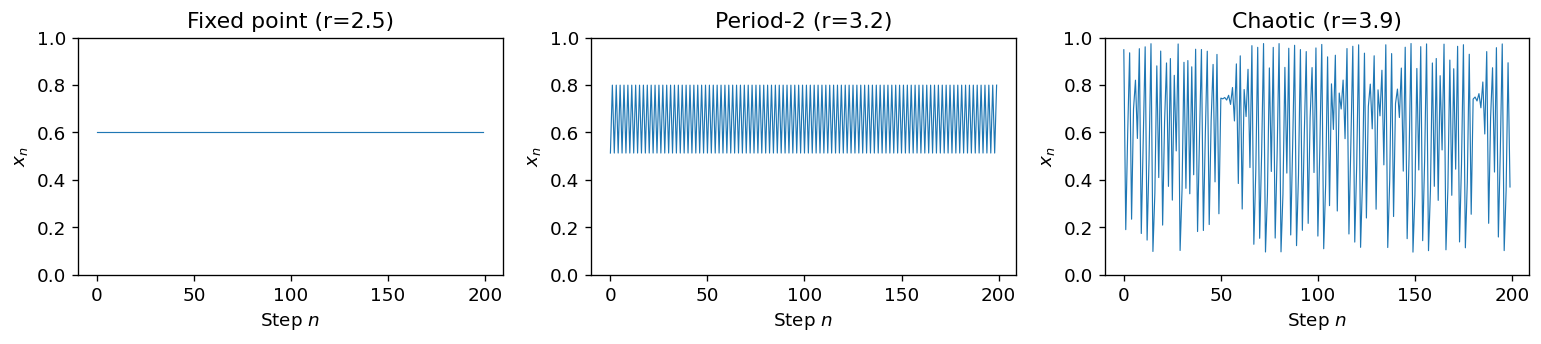

In [ ]:
# Quick visual: trajectories at 3 representative r values
r_examples = [
    (2.5,  'Fixed point (r=2.5)'),
    (3.2,  'Period-2 (r=3.2)'),
    (3.9,  'Chaotic (r=3.9)'),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for ax, (r, title) in zip(axes, r_examples):
    traj = iterate_map(0.4, r, n_steps=600)
    traj = traj[100:]
    ax.plot(traj[:200], lw=0.7)
    ax.set_title(title)
    ax.set_xlabel('Step $n$'); ax.set_ylabel('$x_n$')
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'example_trajectories.png'), bbox_inches='tight')
plt.show()


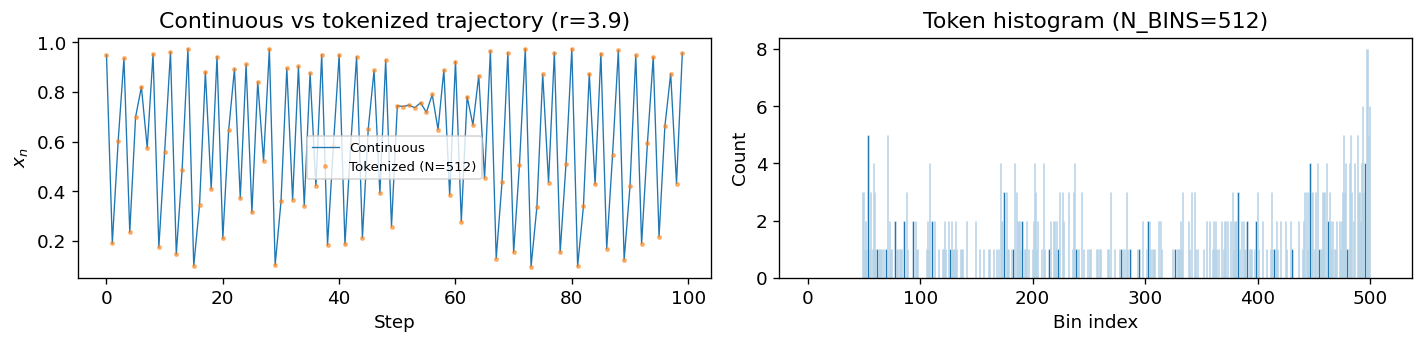

In [ ]:
# Verify tokenization
N_BINS_TEST = 512
traj = iterate_map(0.4, 3.9, 600)[100:]
tokens = tokenize_trajectory(traj, N_BINS_TEST)
centers = detokenize(tokens, N_BINS_TEST)

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(traj[:100], lw=0.8, label='Continuous')
axes[0].plot(centers[:100], 'o', ms=2, alpha=0.5, label=f'Tokenized (N={N_BINS_TEST})')
axes[0].set_title('Continuous vs tokenized trajectory (r=3.9)')
axes[0].legend(fontsize=8)
axes[0].set_xlabel('Step'); axes[0].set_ylabel('$x_n$')

axes[1].hist(tokens[:500], bins=N_BINS_TEST, range=(0, N_BINS_TEST),
             edgecolor='white', linewidth=0.3)
axes[1].set_title(f'Token histogram (N_BINS={N_BINS_TEST})')
axes[1].set_xlabel('Bin index'); axes[1].set_ylabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'tokenization_check.png'), bbox_inches='tight')
plt.show()


In [ ]:
# Verify Lyapunov exponents
for r, expected_sign, desc in [
    (2.5, '<0',    'periodic fixed point'),
    (3.2, '<0',    'period-2 orbit'),
    (3.57, '~0',   'near accumulation point'),
    (4.0, '~0.693','fully chaotic'),
]:
    lya = compute_lyapunov(r, n_steps=200_000)
    print(f'  r={r:.3f} ({desc:30s}):  lambda = {lya:+.4f}   (expect {expected_sign})')


  r=2.500 (periodic fixed point          ):  lambda = -0.6931   (expect <0)
  r=3.200 (period-2 orbit                ):  lambda = -0.9163   (expect <0)
  r=3.570 (near accumulation point       ):  lambda = +0.0108   (expect ~0)
  r=4.000 (fully chaotic                 ):  lambda = +0.6931   (expect ~0.693)


## 6. Build datasets

In [ ]:
# ---------------------------------------------------------------
# Hyperparameters
# ---------------------------------------------------------------
CONTEXT_LEN    = 50
N_BINS         = 64      # number of bins for tokenization
N_TRAJECTORIES = 8_000
TRAJ_LEN       = 150
BURN_IN        = 0
BATCH_SIZE     = 256
R_RANGE        = (0.5, 4.0)
# ---------------------------------------------------------------

train_loader, val_loader, test_loader = make_splits(
    n_trajectories=N_TRAJECTORIES,
    r_range=R_RANGE,
    context_len=CONTEXT_LEN,
    n_bins=N_BINS,
    burn_in=BURN_IN,
    traj_len=TRAJ_LEN,
    batch_size=BATCH_SIZE,
    num_workers=2,
    seed=42,
)

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')

ctx, tgt, r = next(iter(train_loader))
print(f'Context shape : {ctx.shape}   dtype: {ctx.dtype}  (batch, context_len)')
print(f'Target  shape : {tgt.shape}   dtype: {tgt.dtype}  (batch,)')
print(f'Target range  : [{tgt.min().item()}, {tgt.max().item()}]  (should be in [0, {N_BINS-1}])')
print(f'r range       : [{r.min():.3f}, {r.max():.3f}]')


train r: 0.5011004687543044 3.9999195714619296
val r: 0.5090251367030518 3.993535502144425
test r: 0.5014592091608635 3.9991786792002038
Train batches : 2500
Val   batches : 313
Test  batches : 313
Context shape : torch.Size([256, 50])   dtype: torch.int64  (batch, context_len)
Target  shape : torch.Size([256])   dtype: torch.int64  (batch,)
Target range  : [0, 62]  (should be in [0, 63])
r range       : [0.502, 3.992]


## 7. Define and train the transformer

In [ ]:
D_MODEL  = 128
N_HEADS  = 4
N_LAYERS = 4
DROPOUT  = 0.1

model = DiscreteTrajectoryTransformer(
    n_bins=N_BINS,
    context_len=CONTEXT_LEN,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    dropout=DROPOUT,
)

print(f'Transformer parameters: {model.count_parameters():,}')

# Quick forward pass check
dummy = torch.randint(0, N_BINS, (4, CONTEXT_LEN))
out = model(dummy)
print(f'Output shape: {out.shape}  (expect (4, {N_BINS}))')


Transformer parameters: 815,936
Output shape: torch.Size([4, 64])  (expect (4, 64))


/tmp/ipykernel_508/2056136511.py:49: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


In [ ]:
MAX_EPOCHS = 40
LR         = 3e-4
PATIENCE   = 8
RUN_NAME   = 'discrete_transformer'

config = TrainerConfig(
    lr=LR, max_epochs=MAX_EPOCHS, patience=PATIENCE,
    grad_clip=1.0, log_every=200,
    save_dir=CHECKPOINT_DIR, device='auto',
)

trainer = Trainer(
    model=model, train_loader=train_loader,
    val_loader=val_loader, config=config,
    run_name=RUN_NAME,
)

history = trainer.train()


Training on device: cuda
Model parameters: 815,936
Train batches: 2500 | Val batches: 313
------------------------------------------------------------
  Epoch 1 | batch 200/2500 | loss 0.4072 | 9.0s
  Epoch 1 | batch 400/2500 | loss 0.2705 | 16.9s
  Epoch 1 | batch 600/2500 | loss 0.2250 | 25.3s
  Epoch 1 | batch 800/2500 | loss 0.2412 | 33.6s
  Epoch 1 | batch 1000/2500 | loss 0.1752 | 41.7s
  Epoch 1 | batch 1200/2500 | loss 0.2198 | 49.8s
  Epoch 1 | batch 1400/2500 | loss 0.2416 | 58.1s
  Epoch 1 | batch 1600/2500 | loss 0.1339 | 66.4s
  Epoch 1 | batch 1800/2500 | loss 0.1041 | 74.7s
  Epoch 1 | batch 2000/2500 | loss 0.1237 | 83.1s
  Epoch 1 | batch 2200/2500 | loss 0.1402 | 91.6s
  Epoch 1 | batch 2400/2500 | loss 0.1765 | 100.3s
Epoch   1/40 | train 0.2094 | val 0.1058 | 109.1s *
  Epoch 2 | batch 200/2500 | loss 0.1406 | 8.8s
  Epoch 2 | batch 400/2500 | loss 0.1446 | 17.7s
  Epoch 2 | batch 600/2500 | loss 0.1764 | 26.7s
  Epoch 2 | batch 800/2500 | loss 0.1587 | 35.9s
  Epoc

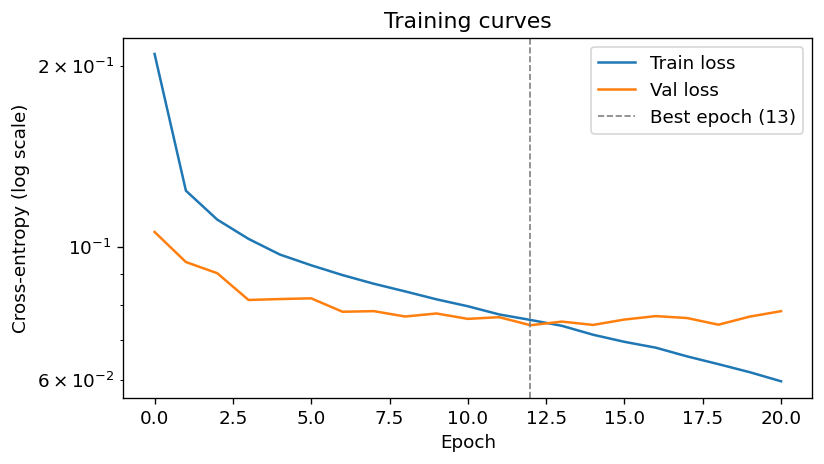

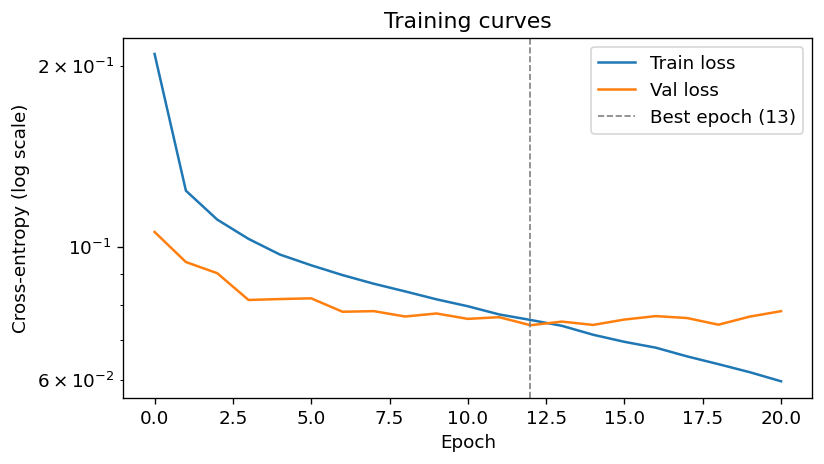

In [ ]:
plot_training_curves(
    history,
    save_path=os.path.join(FIGURE_DIR, 'training_curves.png')
)


## 8. Compute Lyapunov exponents on evaluation grid

Computing Lyapunov exponents (~2 min)...
Computing 800 Lyapunov exponents...
  Lyapunov: 500/800 done
Saved to ./discrete_output/lyapunov_grid.npz
r_grid: (800,), lyapunovs: (800,)


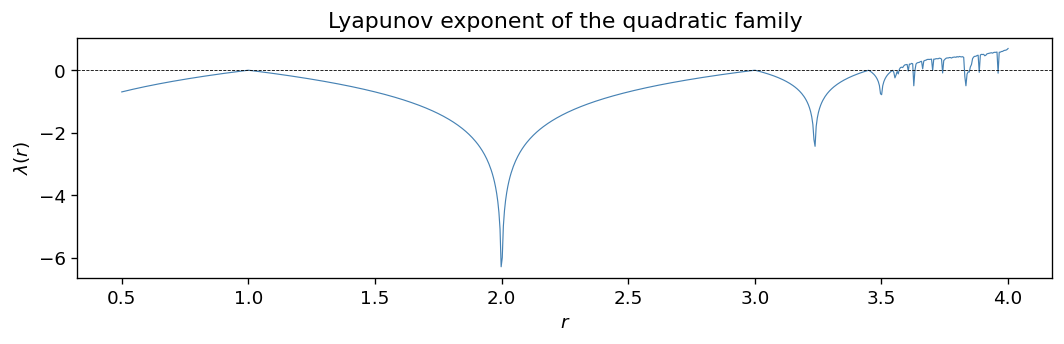

In [ ]:
LYAPUNOV_CACHE = os.path.join(OUTPUT_DIR, 'lyapunov_grid.npz')
N_EVAL_POINTS  = 800

if os.path.exists(LYAPUNOV_CACHE):
    print('Loading cached Lyapunov exponents...')
    cache = np.load(LYAPUNOV_CACHE)
    r_grid    = cache['r_grid']
    lyapunovs = cache['lyapunovs']
else:
    print('Computing Lyapunov exponents (~2 min)...')
    r_grid, lyapunovs = make_eval_grid(
        n_points=N_EVAL_POINTS, r_range=R_RANGE,
        n_lyapunov_steps=100_000,
    )
    np.savez(LYAPUNOV_CACHE, r_grid=r_grid, lyapunovs=lyapunovs)
    print(f'Saved to {LYAPUNOV_CACHE}')

print(f'r_grid: {r_grid.shape}, lyapunovs: {lyapunovs.shape}')

plt.figure(figsize=(9, 3))
plt.plot(r_grid, lyapunovs, lw=0.7, color='steelblue')
plt.axhline(0, color='black', lw=0.5, ls='--')
plt.xlabel('$r$'); plt.ylabel(r'$\lambda(r)$')
plt.title('Lyapunov exponent of the quadratic family')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'lyapunov_curve.png'), bbox_inches='tight')
plt.show()


## 9. Per-$r$ cross-entropy evaluation

In [ ]:
model.eval()

CE_CACHE = os.path.join(OUTPUT_DIR, f'ce_per_r_{RUN_NAME}.npz')

if os.path.exists(CE_CACHE):
    print('Loading cached evaluation...')
    cache = np.load(CE_CACHE)
    ce_per_r  = cache['ce_per_r']
    acc_per_r = cache['acc_per_r']
else:
    print('Evaluating per r value...')
    ce_per_r, acc_per_r = evaluate_per_r_discrete(
        model=model, r_grid=r_grid, device=DEVICE,
        context_len=CONTEXT_LEN, n_bins=N_BINS,
        burn_in=BURN_IN, n_eval_per_r=30, traj_len=TRAJ_LEN,
    )
    np.savez(CE_CACHE, ce_per_r=ce_per_r, acc_per_r=acc_per_r)
    print(f'Saved to {CE_CACHE}')


Evaluating per r value...
  eval: 100/800
  eval: 200/800
  eval: 300/800
  eval: 400/800
  eval: 500/800
  eval: 600/800
  eval: 700/800
  eval: 800/800
Saved to ./discrete_output/ce_per_r_discrete_transformer.npz


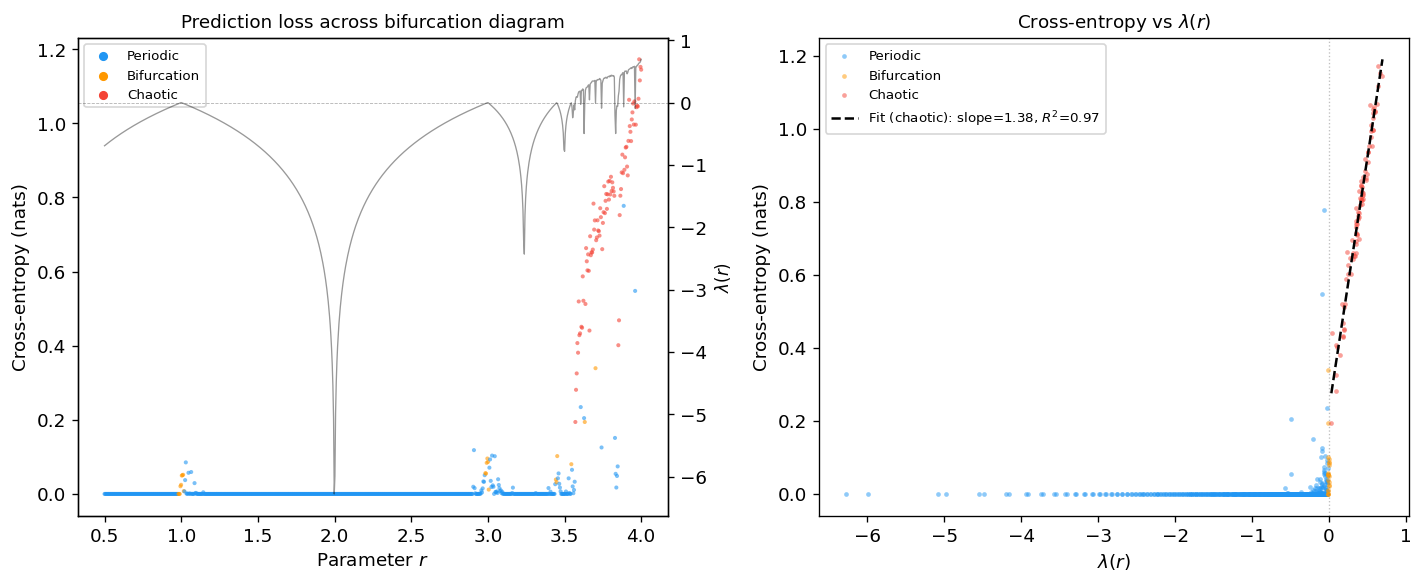

In [ ]:
# THE KEY PLOT: Cross-entropy vs Lyapunov exponent
fig = plot_ce_vs_lyapunov(
    r_grid=r_grid, lyapunovs=lyapunovs,
    ce_per_r=ce_per_r, acc_per_r=acc_per_r,
    save_path=os.path.join(FIGURE_DIR, 'ce_vs_lyapunov.png'),
)


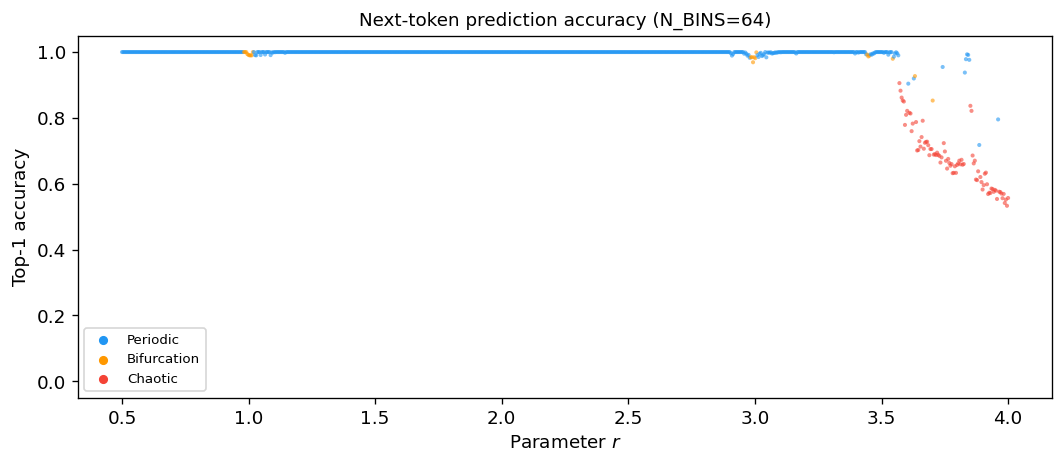

In [ ]:
# Accuracy plot
regimes = np.array([classify_regime(l) for l in lyapunovs])
colors = np.array([REGIME_COLORS[reg] for reg in regimes])

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(r_grid, acc_per_r, c=colors, s=6, alpha=0.6, linewidths=0)
ax.set_xlabel('Parameter $r$', fontsize=11)
ax.set_ylabel('Top-1 accuracy', fontsize=11)
ax.set_title(f'Next-token prediction accuracy (N_BINS={N_BINS})', fontsize=11)
ax.set_ylim(-0.05, 1.05)
for regime, color in REGIME_COLORS.items():
    ax.scatter([], [], c=color, s=20, label=regime.capitalize())
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'accuracy_vs_r.png'), dpi=150, bbox_inches='tight')
plt.show()


## 10. Trajectory comparison (discrete rollout)

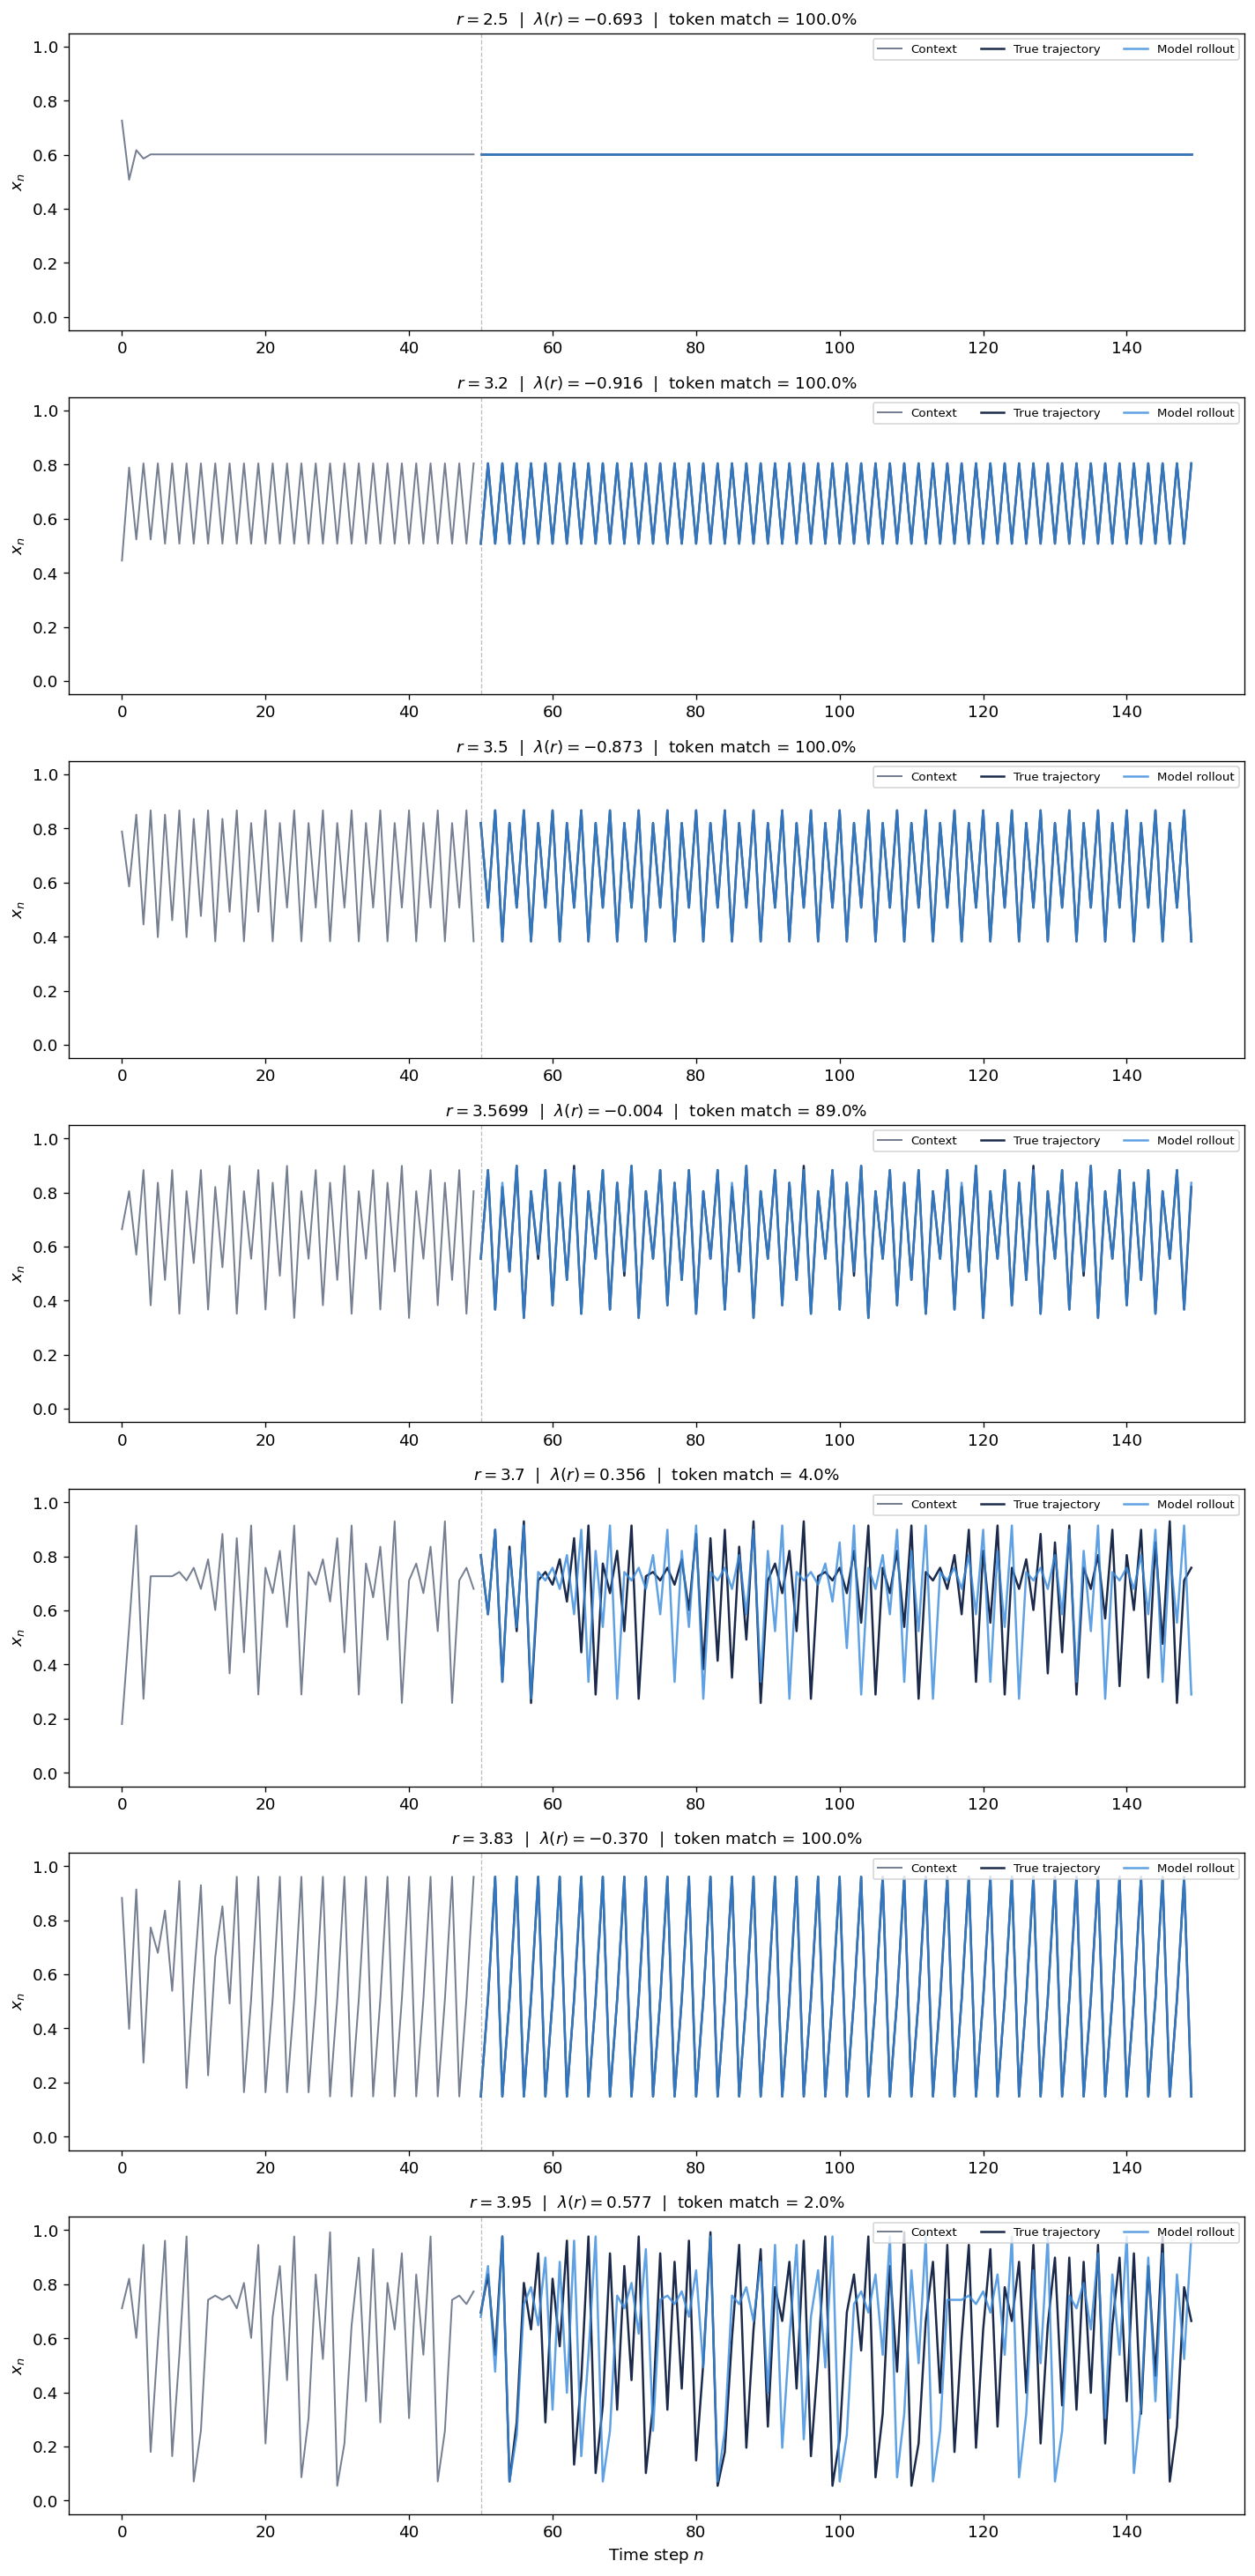

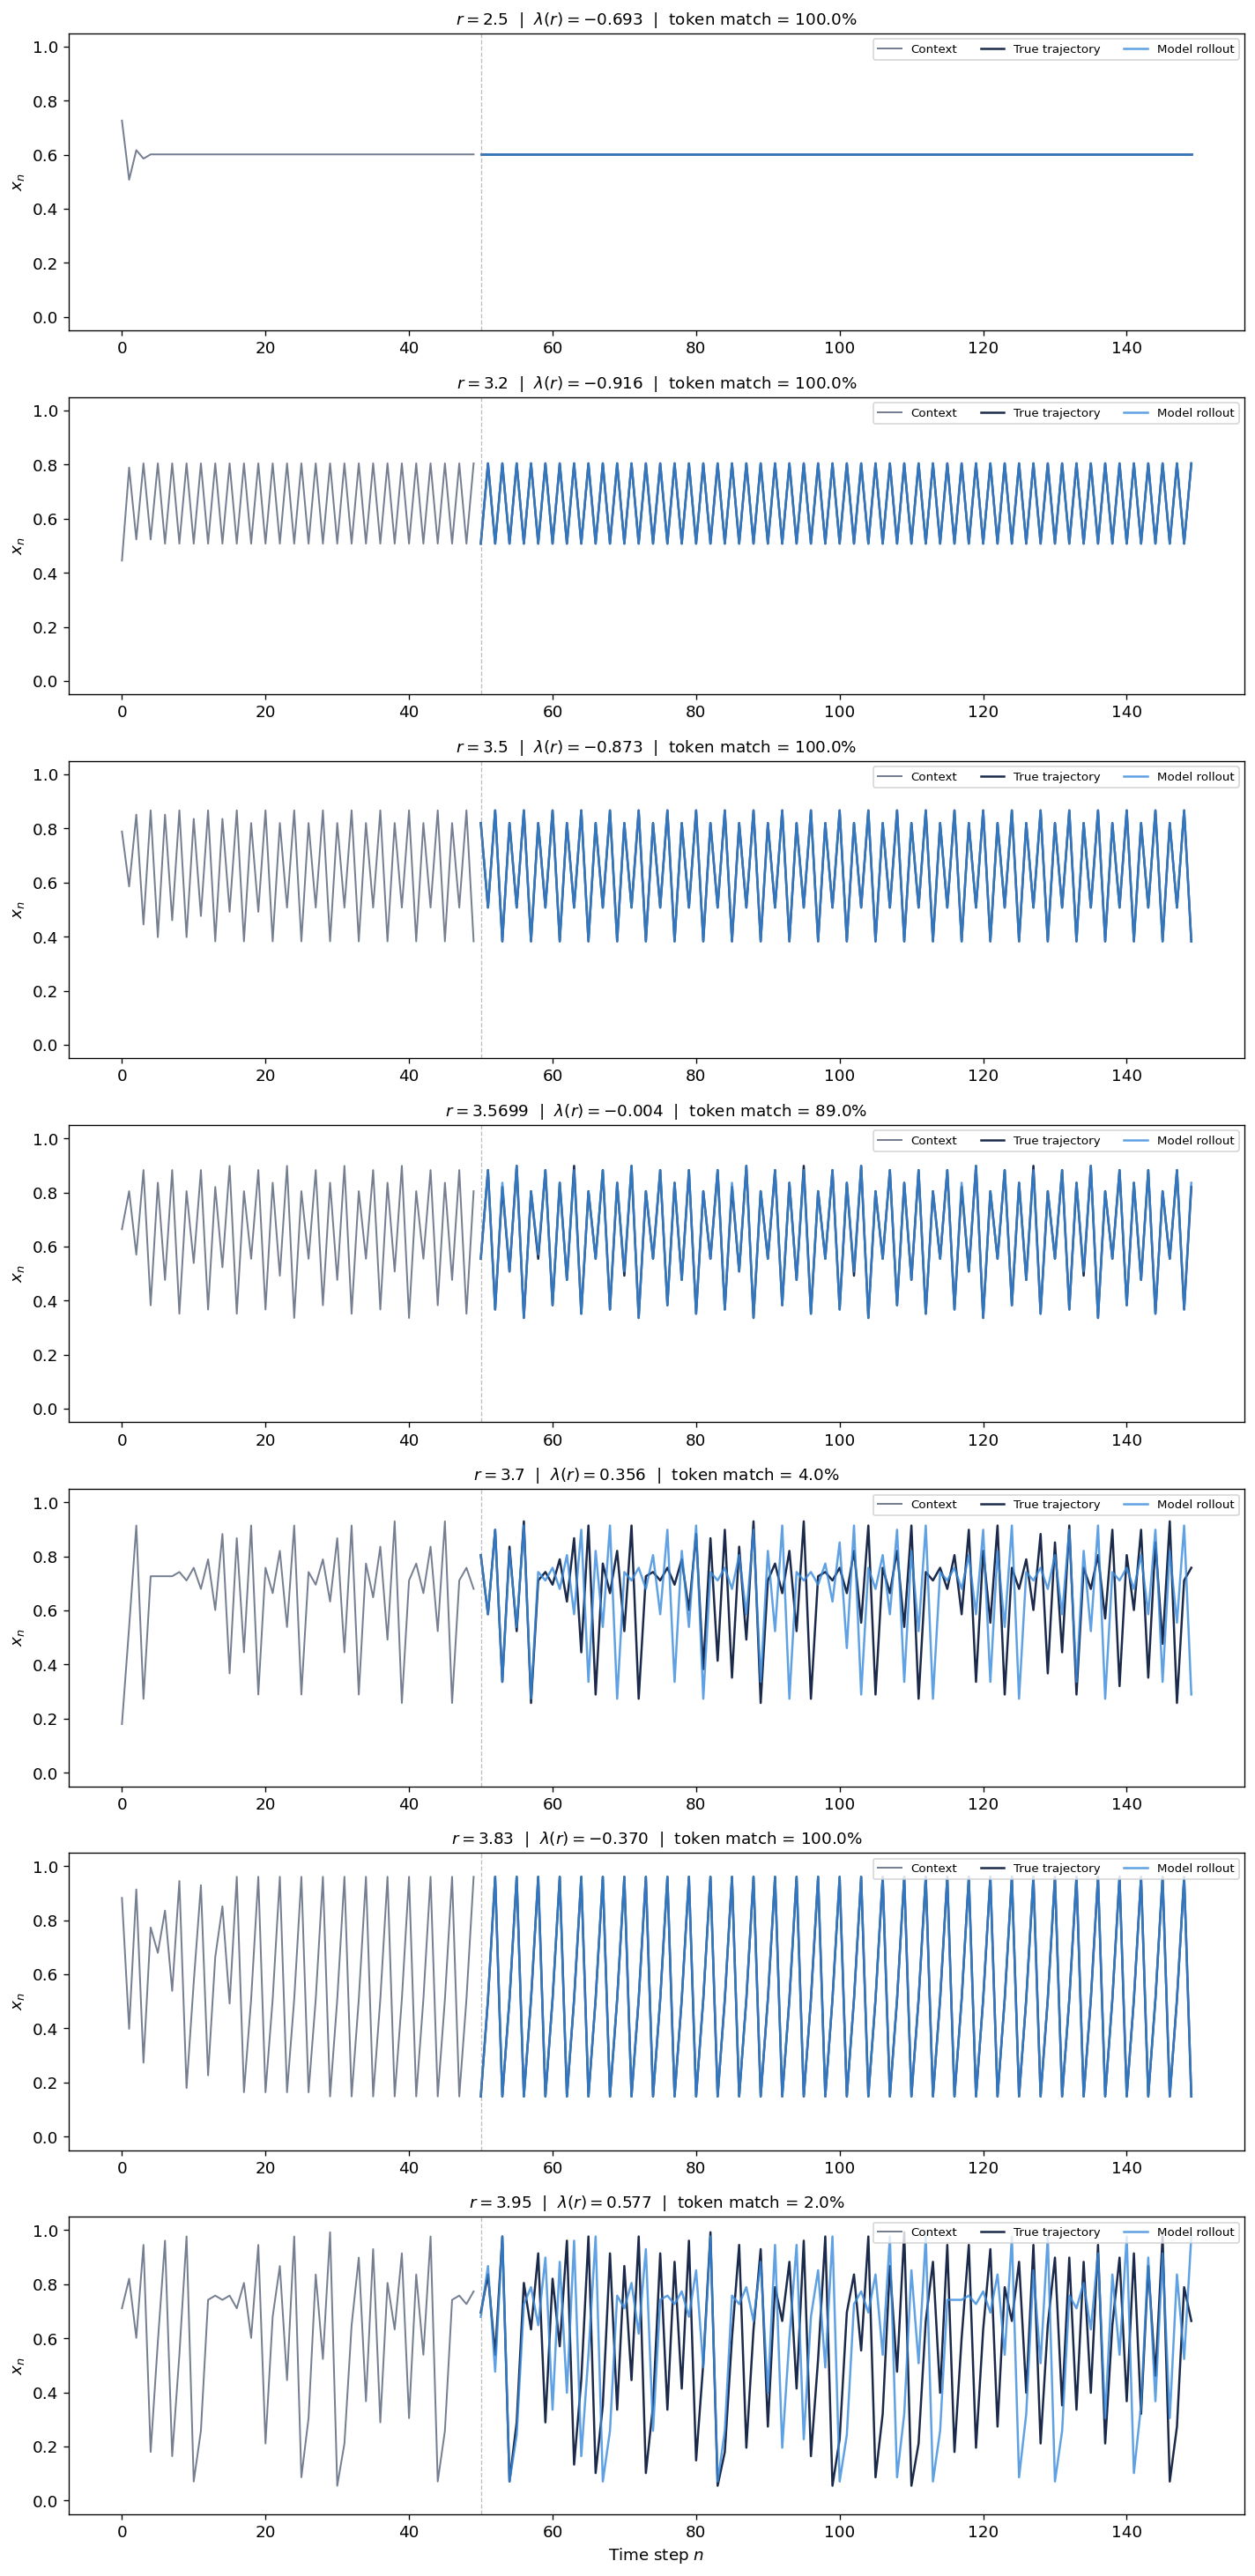

In [ ]:
@torch.no_grad()
def plot_trajectory_comparison_discrete(
    model, r_values, device, context_len, n_bins,
    rollout_steps=100, burn_in=0, seed=42, save_path=None
):
    n = len(r_values)
    fig, axes = plt.subplots(n, 1, figsize=(12, 3.5 * n))
    if n == 1:
        axes = [axes]

    rng = np.random.default_rng(seed)
    model.eval()

    for ax, r in zip(axes, r_values):
        x0 = rng.uniform(0.1, 0.9)
        traj = iterate_map(x0, r, burn_in + context_len + rollout_steps)
        traj = traj[burn_in:]
        tokens = tokenize_trajectory(traj, n_bins)

        context_tokens = tokens[:context_len]
        future_tokens  = tokens[context_len : context_len + rollout_steps]

        ctx_tensor = torch.tensor(context_tokens, dtype=torch.long).unsqueeze(0).to(device)
        rollout_tokens = model.predict_rollout_greedy(ctx_tensor, n_steps=rollout_steps)
        rollout_np = rollout_tokens.squeeze(0).cpu().numpy()

        # Convert to bin centers for plotting
        context_centers = detokenize(context_tokens, n_bins)
        future_centers  = detokenize(future_tokens, n_bins)
        rollout_centers = detokenize(rollout_np, n_bins)

        # Match rate
        match_rate = np.mean(rollout_np == future_tokens)

        t_context = np.arange(context_len)
        t_future  = np.arange(context_len, context_len + rollout_steps)

        ax.plot(t_context, context_centers, color='#1B2A4A', lw=1.2, alpha=0.6, label='Context')
        ax.plot(t_future, future_centers, color='#1B2A4A', lw=1.5, label='True trajectory')
        ax.plot(t_future, rollout_centers, color='#378ADD', lw=1.5, alpha=0.8, label='Model rollout')
        ax.axvline(context_len, color='gray', ls='--', lw=0.8, alpha=0.5)

        lya = compute_lyapunov(r)
        ax.set_title(
            rf'$r = {r}$  |  $\lambda(r) = {lya:.3f}$  |  '
            f'token match = {match_rate:.1%}',
            fontsize=11
        )
        ax.set_ylabel('$x_n$')
        ax.set_ylim(-0.05, 1.05)
        ax.legend(loc='upper right', fontsize=8, ncol=3)

    axes[-1].set_xlabel('Time step $n$')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    return fig


r_values_to_plot = [2.5, 3.2, 3.5, 3.5699, 3.7, 3.83, 3.95]

plot_trajectory_comparison_discrete(
    model=model, r_values=r_values_to_plot, device=DEVICE,
    context_len=CONTEXT_LEN, n_bins=N_BINS,
    rollout_steps=100, burn_in=BURN_IN,
    save_path=os.path.join(FIGURE_DIR, 'trajectory_comparison_discrete.png'),
)


## 11. Cross-family generalization

Test the quadratic-trained model on trajectories from other unimodal map families.
The tokenization uses the same uniform partition of $[0,1]$ into N bins.


In [ ]:
# ================================================================
# Map definitions for other families
# ================================================================

def tent_map(x, s):
    return np.where(x < 0.5, s * x, s * (1.0 - x))

def sine_map(x, r):
    return r * np.sin(np.pi * x)

def cubic_map(x, r):
    y = 2 * x - 1
    z = r * y * (1 - y**2)
    return (z + 1) / 2.0

def iterate_general(x0, map_fn, param, n_steps):
    traj = np.empty(n_steps + 1)
    traj[0] = x0
    for i in range(n_steps):
        traj[i+1] = map_fn(traj[i], param)
        traj[i+1] = np.clip(traj[i+1], 0.0, 1.0)
    return traj

def compute_lyapunov_general(map_fn, deriv_fn, param, n_steps=100_000, x0=0.4):
    x = x0
    for _ in range(1000):
        x = map_fn(x, param)
        x = np.clip(x, 1e-10, 1 - 1e-10)
    log_sum = 0.0
    count = 0
    for _ in range(n_steps):
        d = abs(deriv_fn(x, param))
        if d > 1e-10:
            log_sum += np.log(d)
            count += 1
        x = map_fn(x, param)
        x = np.clip(x, 1e-10, 1 - 1e-10)
    return log_sum / count if count > 0 else 0.0

def tent_deriv(x, s):
    return s if x < 0.5 else -s

def sine_deriv(x, r):
    return r * np.pi * np.cos(np.pi * x)

def cubic_deriv(x, r):
    y = 2 * x - 1
    return r * (1 - 3 * y**2)


@torch.no_grad()
def evaluate_family_discrete(model, map_fn, params, device, context_len,
                              n_bins, burn_in=0, traj_len=150, n_eval=30, seed=99):
    """Evaluate the discrete model on trajectories from a general map family.
    Returns (ce_per_param, acc_per_param)."""
    model.eval()
    rng = np.random.default_rng(seed)
    criterion = nn.CrossEntropyLoss(reduction='mean')
    window_size = context_len + 1
    ce_per_param = np.empty(len(params))
    acc_per_param = np.empty(len(params))

    for i, p in enumerate(params):
        all_contexts, all_targets = [], []

        for _ in range(n_eval):
            x0 = rng.uniform(0.05, 0.95)
            traj = iterate_general(x0, map_fn, p, burn_in + traj_len)
            traj = traj[burn_in:]
            tokens = tokenize_trajectory(traj, n_bins)

            for t in range(len(tokens) - window_size):
                all_contexts.append(tokens[t : t + context_len])
                all_targets.append(tokens[t + context_len])

        ctx = torch.tensor(np.array(all_contexts), dtype=torch.long).to(device)
        tgt = torch.tensor(np.array(all_targets), dtype=torch.long).to(device)
        logits = model(ctx)
        ce_per_param[i] = criterion(logits, tgt).item()
        preds = logits.argmax(dim=-1)
        acc_per_param[i] = (preds == tgt).float().mean().item()

        if (i + 1) % 50 == 0:
            print(f'  {i+1}/{len(params)}  p={p:.3f}  ce={ce_per_param[i]:.3f}')

    return ce_per_param, acc_per_param


# Define families
families = {
    'Quadratic (train)': {
        'map_fn':   lambda x, r: r * x * (1 - x),
        'deriv_fn': lambda x, r: r * (1 - 2*x),
        'params':   np.linspace(0.5, 4.0, 200),
        'color':    '#1B2A4A',
        'class':    'same',
    },
    'Tent map': {
        'map_fn':   tent_map,
        'deriv_fn': tent_deriv,
        'params':   np.linspace(0.2, 2.0, 200),
        'color':    '#1D9E75',
        'class':    'same',
    },
    'Sine map': {
        'map_fn':   sine_map,
        'deriv_fn': sine_deriv,
        'params':   np.linspace(0.1, 1.0, 200),
        'color':    '#378ADD',
        'class':    'same',
    },
    'Cubic map': {
        'map_fn':   cubic_map,
        'deriv_fn': cubic_deriv,
        'params':   np.linspace(0.1, 1.0, 200),
        'color':    '#D85A30',
        'class':    'different',
    },
}

# Evaluate and cache
family_ce = {}
family_acc = {}
family_lya = {}

for name, fam in families.items():
    cache_key = name.replace(' ', '_').replace('(', '').replace(')', '')
    ce_cache = os.path.join(OUTPUT_DIR, f'phase3_ce_{cache_key}.npz')
    lya_cache = os.path.join(OUTPUT_DIR, f'phase3_lya_{cache_key}.npy')

    # Lyapunov
    if os.path.exists(lya_cache):
        family_lya[name] = np.load(lya_cache)
    else:
        print(f'Computing Lyapunov: {name}')
        lyas = np.array([
            compute_lyapunov_general(fam['map_fn'], fam['deriv_fn'], p)
            for p in fam['params']
        ])
        np.save(lya_cache, lyas)
        family_lya[name] = lyas

    # CE and accuracy
    if os.path.exists(ce_cache):
        print(f'Loading cached: {name}')
        cache = np.load(ce_cache)
        family_ce[name] = cache['ce']
        family_acc[name] = cache['acc']
    else:
        print(f'Evaluating: {name}')
        ce, acc = evaluate_family_discrete(
            model=model, map_fn=fam['map_fn'],
            params=fam['params'], device=DEVICE,
            context_len=CONTEXT_LEN, n_bins=N_BINS,
            burn_in=BURN_IN, traj_len=TRAJ_LEN, n_eval=30,
        )
        np.savez(ce_cache, ce=ce, acc=acc)
        family_ce[name] = ce
        family_acc[name] = acc
        print(f'  Saved.')


Computing Lyapunov: Quadratic (train)
Evaluating: Quadratic (train)
  50/200  p=1.362  ce=0.000
  100/200  p=2.241  ce=0.000
  150/200  p=3.121  ce=0.000
  200/200  p=4.000  ce=1.232
  Saved.
Computing Lyapunov: Tent map
Evaluating: Tent map
  50/200  p=0.643  ce=0.000
  100/200  p=1.095  ce=1.765
  150/200  p=1.548  ce=11.322
  200/200  p=2.000  ce=0.906
  Saved.
Computing Lyapunov: Sine map
Evaluating: Sine map
  50/200  p=0.322  ce=0.144
  100/200  p=0.548  ce=0.000
  150/200  p=0.774  ce=0.104
  200/200  p=1.000  ce=5.990
  Saved.
Computing Lyapunov: Cubic map
Evaluating: Cubic map
  50/200  p=0.322  ce=0.065
  100/200  p=0.548  ce=0.000
  150/200  p=0.774  ce=0.000
  200/200  p=1.000  ce=3.665
  Saved.


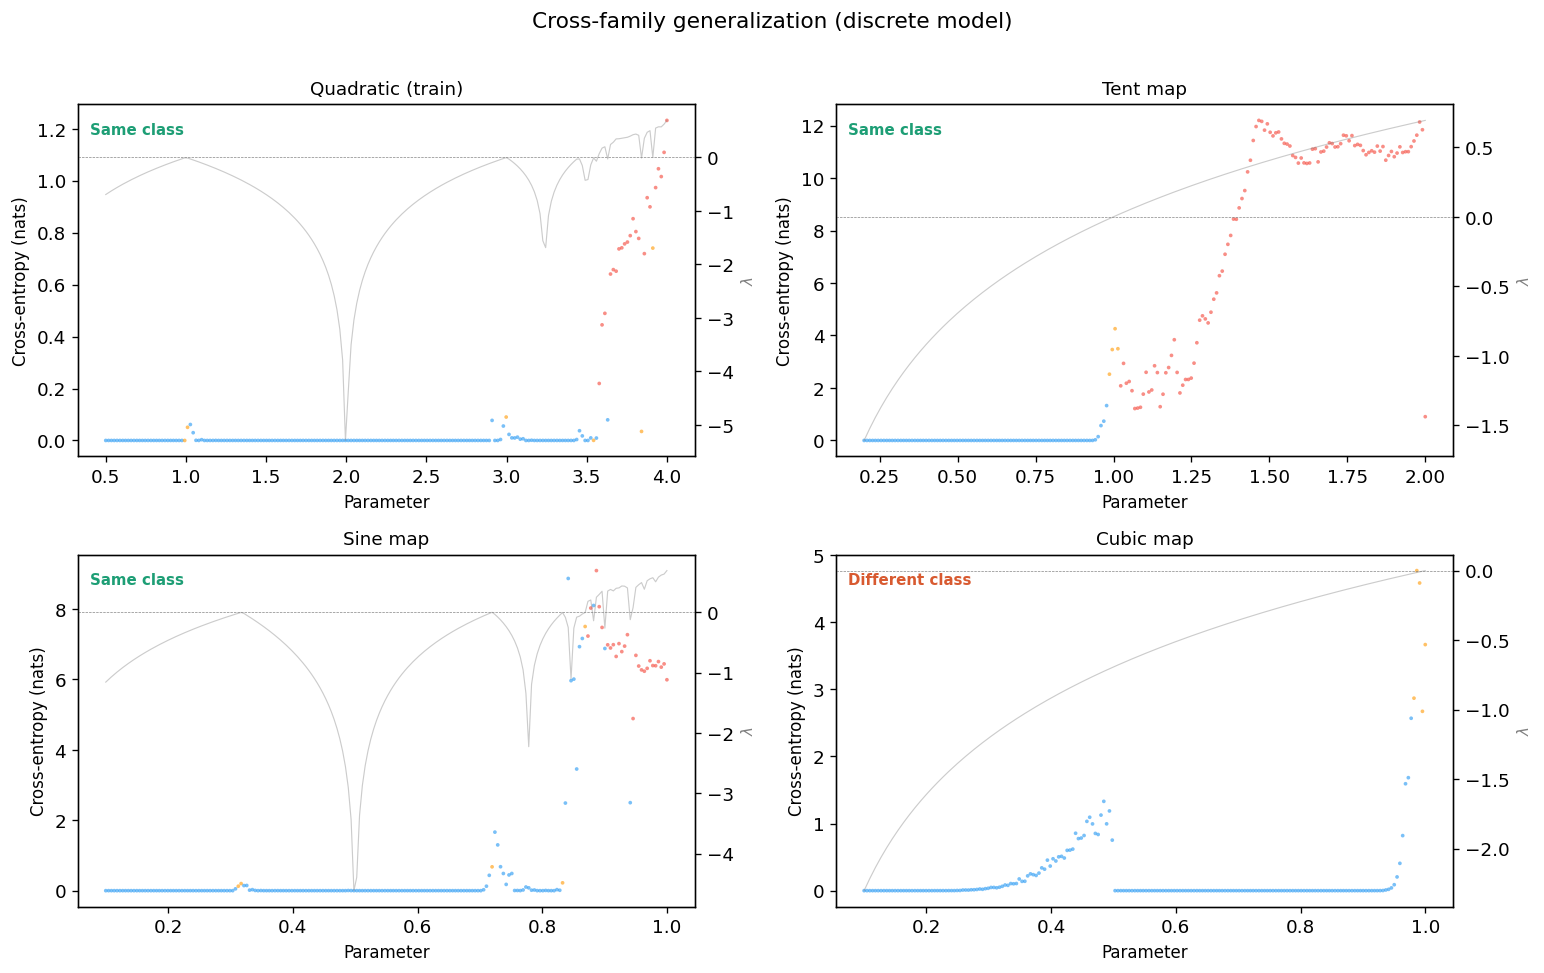

In [ ]:
# Plot cross-entropy vs parameter for each family
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for ax, (name, fam) in zip(axes, families.items()):
    params = fam['params']
    ce     = family_ce[name]
    lyas   = family_lya[name]

    colors = np.where(lyas > 0.02, '#F44336',
             np.where(lyas < -0.02, '#2196F3', '#FF9800'))

    ax.scatter(params, ce, c=colors, s=5, alpha=0.6, linewidths=0)

    ax2 = ax.twinx()
    ax2.plot(params, lyas, color='gray', lw=0.7, alpha=0.4)
    ax2.axhline(0, color='gray', lw=0.4, ls='--')
    ax2.set_ylabel(r'$\lambda$', fontsize=9, color='gray')

    ax.set_xlabel('Parameter', fontsize=10)
    ax.set_ylabel('Cross-entropy (nats)', fontsize=10)
    ax.set_title(name, fontsize=11)

    label = 'Same class' if fam['class'] == 'same' else 'Different class'
    color = '#1D9E75' if fam['class'] == 'same' else '#D85A30'
    ax.text(0.02, 0.95, label, transform=ax.transAxes,
            fontsize=9, color=color, fontweight='bold', va='top')

plt.suptitle('Cross-family generalization (discrete model)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'phase3_ce_vs_param.png'),
            dpi=150, bbox_inches='tight')
plt.show()
